# Day 6 Baseline 建模：AI4I 2020 设备故障预测

本 notebook 的目标是完成第一版最小可行 baseline：在不做复杂特征工程、不做复杂调参的前提下，使用当前项目已经理解过的核心业务变量，训练一个可以解释、可以展示、可以衔接 Day 7 总结的故障预测模型。

当前阶段重点不是刷分，而是回答：仅使用基础运行状态字段时，模型能否识别少数故障样本。

## 1. Day 6 建模边界

- 目标变量：CSV 原始字段 `Machine failure`，对应 SQL 表中的 `Machine_failure`。
- 当前不使用 `TWF/HDF/PWF/OSF/RNF` 作为特征，因为它们是具体故障原因标记，更适合做解释或边界提醒；直接用于预测总故障标签容易造成标签泄漏。
- 当前不使用 `UDI` 和 `Product ID`，因为它们更像记录编号和产品编号，不是稳定的运行状态变量。
- 当前只做最小 baseline：Logistic Regression 和 XGBoost。
- 评价重点放在故障类 `1` 的 precision、recall、F1 和 confusion matrix，而不是只看 accuracy。

In [1]:
# 导入基础数据处理、建模和评估库
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier

# 统一随机种子，保证结果可复现
RANDOM_STATE = 42

## 2. 读取数据

当前 notebook 默认从项目根目录 `C:\2020 AI4I\ai4i_predictive_maintenance` 运行，因此直接读取 `data/raw/ai4i2020.csv`。

In [5]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

print("数据规模：", df.shape)
df.head()

数据规模： (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
# 快速确认字段和目标变量分布，避免建模前拿错列
print("字段列表：")
print(df.columns.tolist())

print("\n目标变量分布：")
print(df["Machine failure"].value_counts().sort_index())

print("\n目标变量占比：")
print((df["Machine failure"].value_counts(normalize=True).sort_index() * 100).round(2))

字段列表：
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

目标变量分布：
Machine failure
0    9661
1     339
Name: count, dtype: int64

目标变量占比：
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


## 3. 选择特征与目标

特征选择沿用 Day 3 / Day 5 已经观察过的业务变量：产品类型、温度、转速、扭矩、刀具磨损。这里先不新增复杂组合特征，目的是建立第一版可比较的基础结果。

In [7]:
target_col = "Machine failure"

feature_cols = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

leakage_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
id_cols = ["UDI", "Product ID"]

print("本次使用的特征：", feature_cols)
print("本次暂不使用的编号字段：", id_cols)
print("本次暂不作为预测特征的故障原因字段：", leakage_cols)

X_raw = df[feature_cols].copy()
y = df[target_col].copy()

本次使用的特征： ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
本次暂不使用的编号字段： ['UDI', 'Product ID']
本次暂不作为预测特征的故障原因字段： ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']


## 4. 基础预处理

`Type` 是类别字段，需要做 one-hot 编码。其余数值字段保持原始含义，不在第一版 baseline 中做复杂变换。

In [8]:
# 对 Type 做最基础的 one-hot 编码；保留全部类别，方便后续解释
X = pd.get_dummies(X_raw, columns=["Type"], drop_first=False)

# XGBoost 不接受包含 [] 或 < 的特征名，这里只对建模矩阵列名做安全化处理
# 原始数据字段和业务含义不变，后续解释仍然可以对应回原始变量
safe_columns = (
    pd.Series(X.columns)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "lt", regex=False)
    .str.replace(">", "gt", regex=False)
    .str.replace(" ", "_", regex=False)
)
X.columns = safe_columns

print("建模特征列：")
print(X.columns.tolist())
print("\n建模矩阵规模：", X.shape)
X.head()

建模特征列：
['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_H', 'Type_L', 'Type_M']

建模矩阵规模： (10000, 8)


,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,False,True
1,298.2,308.7,1408,46.3,3,False,True,False
2,298.1,308.5,1498,49.4,5,False,True,False
3,298.2,308.6,1433,39.5,7,False,True,False
4,298.2,308.7,1408,40.0,9,False,True,False


## 5. 划分训练集和测试集

故障样本占比只有约 3.39%，因此划分数据时使用 `stratify=y`，让训练集和测试集中的故障比例尽量保持一致。

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("训练集规模：", X_train.shape)
print("测试集规模：", X_test.shape)

print("\n训练集目标分布：")
print(y_train.value_counts().sort_index())

print("\n测试集目标分布：")
print(y_test.value_counts().sort_index())

训练集规模： (8000, 8)
测试集规模： (2000, 8)

训练集目标分布：
Machine failure
0    7729
1     271
Name: count, dtype: int64

测试集目标分布：
Machine failure
0    1932
1      68
Name: count, dtype: int64


## 6. 训练 baseline 模型

这里保留两个模型：

1. `Logistic Regression`：可解释性强，作为最基础的线性 baseline。
2. `XGBoost`：训练速度快，能捕捉非线性关系，作为当前 MVP 阶段的树模型 baseline。

由于故障样本明显少于正常样本，两个模型都使用最基础的不平衡处理参数，但不做复杂采样和调参。

In [10]:
# Logistic Regression 对特征尺度敏感，因此只给它做标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
log_reg.fit(X_train_scaled, y_train)

# XGBoost 使用 scale_pos_weight 处理类别不平衡
negative_cnt = (y_train == 0).sum()
positive_cnt = (y_train == 1).sum()
scale_pos_weight = negative_cnt / positive_cnt

xgb_model = XGBClassifier(
    n_estimators=120,
    max_depth=3,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)

print("模型训练完成。")
print("XGBoost scale_pos_weight：", round(scale_pos_weight, 2))

模型训练完成。
XGBoost scale_pos_weight： 28.52


## 7. 模型评估

本项目的故障样本很少，因此不能只看 accuracy。这里重点看故障类 `1` 的 precision、recall 和 F1-score。

- precision：模型预测为故障的样本中，有多少是真的故障。
- recall：真实故障样本中，有多少被模型识别出来。
- F1-score：precision 和 recall 的综合表现。

In [11]:
def evaluate_model(model_name, y_true, y_pred):
    """输出基础分类指标，并返回故障类的核心指标。"""
    print(f"===== {model_name} =====")
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        "model": model_name,
        "accuracy": report["accuracy"],
        "failure_precision": report["1"]["precision"],
        "failure_recall": report["1"]["recall"],
        "failure_f1": report["1"]["f1-score"],
    }


log_reg_pred = log_reg.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test)

results = []
results.append(evaluate_model("Logistic Regression", y_test, log_reg_pred))
results.append(evaluate_model("XGBoost", y_test, xgb_pred))

===== Logistic Regression =====
Confusion matrix:
[[1594  338]
 [  12   56]]

Classification report:
              precision    recall  f1-score   support

           0      0.993     0.825     0.901      1932
           1      0.142     0.824     0.242        68

    accuracy                          0.825      2000
   macro avg      0.567     0.824     0.572      2000
weighted avg      0.964     0.825     0.879      2000

===== XGBoost =====
Confusion matrix:
[[1787  145]
 [   8   60]]

Classification report:
              precision    recall  f1-score   support

           0      0.996     0.925     0.959      1932
           1      0.293     0.882     0.440        68

    accuracy                          0.923      2000
   macro avg      0.644     0.904     0.699      2000
weighted avg      0.972     0.923     0.941      2000



In [12]:
metrics_df = pd.DataFrame(results)
metrics_df = metrics_df.sort_values("failure_f1", ascending=False).reset_index(drop=True)
metrics_df

,model,accuracy,failure_precision,failure_recall,failure_f1
0,XGBoost,0.9235,0.292683,0.882353,0.439560
1,Logistic Regression,0.8250,0.142132,0.823529,0.242424


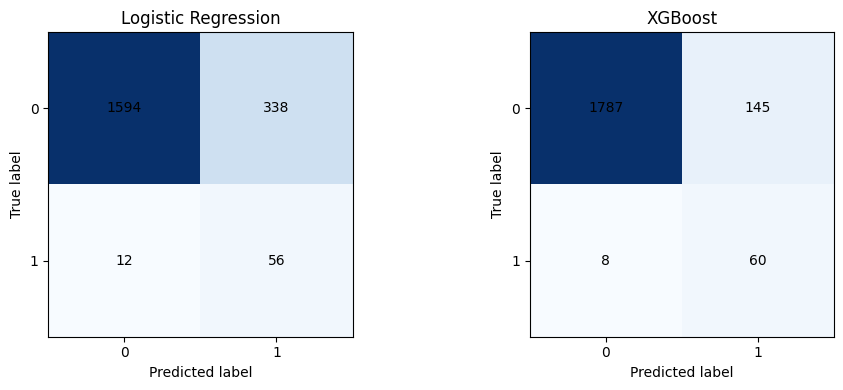

In [13]:
# 用图表查看两个模型的混淆矩阵，方便 Day 7 做项目展示时引用
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, model_name, y_pred in zip(
    axes,
    ["Logistic Regression", "XGBoost"],
    [log_reg_pred, xgb_pred],
):
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

## 8. 轻量查看 XGBoost 特征重要性

这里不是做复杂解释模型，只是查看第一版树模型更关注哪些基础变量，方便和 Day 3 / Day 5 的业务发现互相印证。

In [14]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
2,Rotational_speed_rpm,0.282618
3,Torque_Nm,0.246789
4,Tool_wear_min,0.212733
0,Air_temperature_K,0.130895
1,Process_temperature_K,0.056494
7,Type_M,0.041198
6,Type_L,0.023335
5,Type_H,0.005938


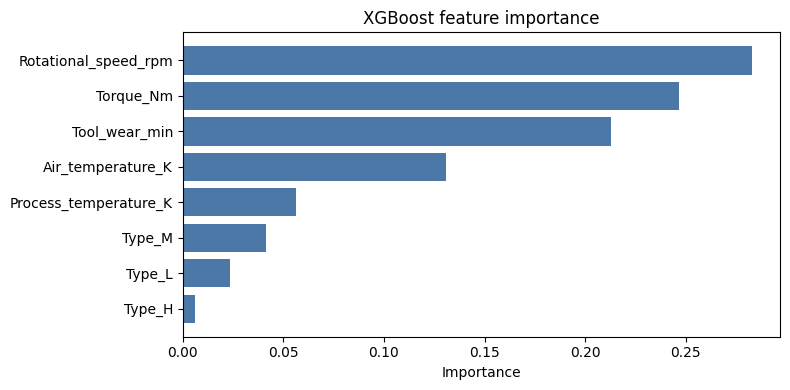

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feature_importance["feature"], feature_importance["importance"], color="#4C78A8")
ax.invert_yaxis()
ax.set_title("XGBoost feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. Day 6 小结

本次 baseline 的目标是先跑通从业务分析到建模评估的最小闭环。当前模型只使用基础运行状态字段和产品类型，没有加入复杂特征工程，也没有使用具体故障原因字段 `TWF/HDF/PWF/OSF/RNF`，因此结果可以作为后续迭代的基础对照。

解读结果时需要优先关注故障类 `1` 的 recall 和 F1-score。如果模型 accuracy 很高但故障类 recall 很低，说明模型主要学会了识别多数类正常样本，对预测性维护场景的价值有限。

Day 7 可以基于本 notebook 的评估结果，整理 README、summary 和关键图表；如果后续继续迭代，再考虑加入少量业务特征，例如温差、功率近似值或高磨损标记。

## 10. 阈值调优与 PR 曲线分析

前面的 XGBoost baseline 默认使用 `0.5` 作为分类阈值。这个阈值可以作为对照，但不一定是预测性维护场景下最合理的业务阈值。

本节只基于已经训练好的 `xgb_model` 和测试集预测概率做阈值分析，不新增特征、不调参、不做交叉验证，也不改变前面的 baseline 结果。目标是在保留较高故障召回率的同时，观察是否可以通过阈值选择提升 precision / F1，并减少不必要的误报。


In [ ]:
import numpy as np

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
)


### 10.1 保留默认 0.5 阈值结果

这里先把当前 XGBoost 默认阈值 `0.5` 的结果单独整理出来，作为后续阈值比较的 baseline 对照。


In [ ]:
y_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred_05 = (y_proba >= 0.5).astype(int)

cm_05 = confusion_matrix(y_test, xgb_pred_05, labels=[0, 1])
tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()

default_threshold_result = pd.DataFrame([
    {
        "threshold": 0.5,
        "precision": precision_score(y_test, xgb_pred_05, zero_division=0),
        "recall": recall_score(y_test, xgb_pred_05, zero_division=0),
        "f1": f1_score(y_test, xgb_pred_05, zero_division=0),
        "f2": fbeta_score(y_test, xgb_pred_05, beta=2, zero_division=0),
        "TP": tp_05,
        "FP": fp_05,
        "TN": tn_05,
        "FN": fn_05,
    }
])

print("XGBoost default threshold = 0.5")
print("Confusion matrix:")
print(cm_05)
default_threshold_result.round(3)


### 10.2 Precision-Recall Curve 与 Average Precision

由于故障样本占比很低，Precision-Recall Curve 比 ROC 曲线更适合观察少数故障类的识别质量。Average Precision 可以理解为 PR 曲线下的综合表现，数值越高表示模型越能把真实故障样本排在更高风险位置。


In [ ]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba)
average_precision = average_precision_score(y_test, y_proba)
baseline_failure_rate = y_test.mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_curve, precision_curve, color="#4C78A8", linewidth=2, label=f"XGBoost AP = {average_precision:.3f}")
ax.axhline(
    baseline_failure_rate,
    color="#E45756",
    linestyle="--",
    linewidth=1.5,
    label=f"Test failure rate = {baseline_failure_rate:.3f}",
)
ax.set_title("XGBoost Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("Average Precision / PR-AUC:", round(average_precision, 3))
print("Test failure rate baseline:", round(baseline_failure_rate, 3))


### 10.3 Threshold 对比表

下面遍历 `0.10` 到 `0.90` 的多个阈值，观察每个阈值下的 precision、recall、F1、F2 和混淆矩阵组成。F2 比 F1 更重视 recall，适合预测性维护中“漏报故障成本较高”的场景参考。


In [ ]:
def threshold_metrics(y_true, y_score, threshold):
    """计算单个阈值下的核心分类指标和混淆矩阵组成。"""
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    }

thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)
threshold_table = pd.DataFrame([
    threshold_metrics(y_test, y_proba, threshold)
    for threshold in thresholds
])

threshold_table.round(3)


### 10.4 候选阈值选择

这里保留 4 个关键候选点：默认阈值、F1 最优阈值、F2 最优阈值，以及一个偏向召回率的预测性维护候选阈值。

召回优先候选阈值选择 `0.40`：相比默认 `0.50`，它会多抓回一部分故障样本，但误报也会增加，因此它更适合“漏报成本明显高于误报成本”的场景，而不是直接作为唯一最佳阈值。


In [ ]:
def get_threshold_row(table, threshold):
    return table.loc[np.isclose(table["threshold"], threshold)].iloc[0]

f1_best_row = threshold_table.loc[threshold_table["f1"].idxmax()]
f2_best_row = threshold_table.loc[threshold_table["f2"].idxmax()]
default_row = get_threshold_row(threshold_table, 0.50)
recall_oriented_row = get_threshold_row(threshold_table, 0.40)

candidate_thresholds = pd.DataFrame([
    {"candidate": "Default 0.50", "reason": "当前 XGBoost 默认判定阈值", **default_row.to_dict()},
    {"candidate": "Recall-oriented 0.40", "reason": "减少漏报，适合更重视故障召回的维护筛查", **recall_oriented_row.to_dict()},
    {"candidate": "Best F2", "reason": "在本轮阈值网格中更重视 recall 的综合最优", **f2_best_row.to_dict()},
    {"candidate": "Best F1", "reason": "在本轮阈值网格中 precision/recall 平衡最优", **f1_best_row.to_dict()},
])

candidate_thresholds = candidate_thresholds[
    ["candidate", "reason", "threshold", "precision", "recall", "f1", "f2", "TP", "FP", "TN", "FN"]
]

candidate_thresholds.round(3)


### 10.5 候选阈值的混淆矩阵

下面只输出 4 个关键阈值的指标和混淆矩阵，避免被过多阈值淹没。混淆矩阵格式为：行是真实标签，列是预测标签。


In [ ]:
for _, row in candidate_thresholds.iterrows():
    threshold = row["threshold"]
    y_pred_threshold = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_threshold, labels=[0, 1])

    print(f"===== {row['candidate']} | threshold = {threshold:.2f} =====")
    print(
        f"precision={row['precision']:.3f}, "
        f"recall={row['recall']:.3f}, "
        f"f1={row['f1']:.3f}, "
        f"f2={row['f2']:.3f}"
    )
    print(pd.DataFrame(cm, index=["True 0", "True 1"], columns=["Pred 0", "Pred 1"]))
    print()


## 11. Day1 阈值调优小结

默认 `0.5` 阈值不是天然最合理的业务阈值，它只是分类模型常用的默认切分点。在当前测试集上，默认阈值下 XGBoost 的故障类表现为 `precision=0.293`、`recall=0.882`、`F1=0.440`、`F2=0.629`，能够抓回多数故障，但误报仍然较多。

本轮 XGBoost 的 Average Precision / PR-AUC 约为 `0.721`，明显高于测试集故障率基线 `0.034`。这说明模型输出的故障概率排序是有价值的：真实故障样本整体更容易被排到高风险区间。因此，阈值调优是有意义的，而不是只盯着默认 `0.5`。

如果业务更怕漏报，可以考虑偏低一点的阈值，例如 `0.40`。它把 recall 从 `0.882` 提高到约 `0.926`，FN 从 `8` 降到 `5`，但 FP 会从 `145` 增加到 `175`。这适合把模型作为维护风险筛查工具，但需要接受更多误报。

如果业务更怕误报，应倾向更高阈值，例如本轮 F1 最优附近的 `0.85`。它的 precision 提升到约 `0.641`，FP 降到 `28`，但 recall 下降到约 `0.735`，FN 增加到 `18`。这更适合检修资源紧张、误报成本较高的场景。

从综合指标看，本轮阈值网格中 `0.80` 的 F2 最优，`0.85` 的 F1 最优。若后续需要一个兼顾业务召回和误报控制的分析参考点，可以优先保留 `0.80` 作为候选阈值；若更强调筛查召回，则保留 `0.40` 作为召回优先候选阈值。

当前阈值调优仍然有局限：它只基于一次 train/test split，没有验证阈值在不同数据划分下是否稳定；并且没有增加任何新的业务信号，因此只能调整“判定边界”，不能让模型学到更多故障规律。下一步更适合进入少量业务特征工程，例如温差、功率近似值、高磨损标记或高扭矩低转速组合，而不是继续盲目调参。
